IsabeLA Vieira Rodrigues

# Lab 10: Convolutional Layers

**Computer Vision Course**

Building on Lab 9, today you'll see how the scale-space ideas you built by hand translate directly into **learnable convolutional layers** in a neural network.

**What you'll learn:**
- How convolutional layers generalise handcrafted filters
- The role of filter count, kernel size, and bias
- How ReLU activations change learning dynamics
- Why more parameters do not always mean better results

**What you'll build:**
- A baseline dense network (benchmark from Lab 6)
- A single convolutional layer network
- A two-layer convolutional network
- Variants exploring bias and activation

**Why this matters:**
In Lab 9 you hand-designed Gaussian filters and Laplacians. Today the network **learns those filters automatically** from data!

**Connection to previous labs:**
- Lab 7: Learned convolution and Gaussian smoothing
- Lab 8: Built edge detectors (Sobel, Laplacian, LoG)
- Lab 9: Applied edge detection across multiple scales
- Lab 10 (today): See how CNNs learn multi-scale features automatically!

## Setup

In [8]:
"""
Computer Vision Course - Lab 10: Convolutional Layers

This cell sets up the environment.
Works automatically for both local and Google Colab!
"""

import os
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

print("=" * 60)
print("Computer Vision - Lab 10: Convolutional Layers")
print("=" * 60)

if IN_COLAB:
    print("\n🔵 Running on Google Colab")
    print("-" * 60)

    if not os.path.exists('computer-vision'):
        print("📥 Cloning repository...")
        !git clone https://github.com/mjck/computer-vision.git
        print("✓ Repository cloned successfully")
    else:
        !git -C computer-vision pull
        print("✓ Repository updated successfully")

    %cd computer-vision/labs/lab10_conv_layers
    print(f"✓ Current directory: {os.getcwd()}")

    sys.path.insert(0, '/content/computer-vision')
    print("✓ Python path configured")

    print("-" * 60)
    print("🟢 Colab setup complete!\n")

else:
    print("\n🟢 Running locally")
    print("-" * 60)
    print(f"✓ Current directory: {os.getcwd()}")

    repo_root = os.path.abspath('../..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    print(f"✓ Repository root: {repo_root}")

    print("-" * 60)
    print("🟢 Local setup complete!\n")

print("=" * 60)
print("✅ Environment ready!")
print("=" * 60)

Computer Vision - Lab 10: Convolutional Layers

🔵 Running on Google Colab
------------------------------------------------------------
📥 Cloning repository...
Cloning into 'computer-vision'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 360 (delta 73), reused 102 (delta 28), pack-reused 210 (from 1)
Receiving objects: 100% (360/360), 6.22 MiB | 4.42 MiB/s, done.
Resolving deltas: 100% (169/169), done.
Filtering content: 100% (88/88), 27.29 MiB | 16.33 MiB/s, done.
✓ Repository cloned successfully
/content/computer-vision/labs/lab10_conv_layers/computer-vision/labs/lab10_conv_layers
✓ Current directory: /content/computer-vision/labs/lab10_conv_layers/computer-vision/labs/lab10_conv_layers
✓ Python path configured
------------------------------------------------------------
🟢 Colab setup complete!

✅ Environment ready!


## Import Libraries

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Import course utilities
try:
    from sdx import plot_loss
    print("✓ sdx module loaded")
except ImportError as e:
    print(f"❌ Could not import sdx: {e}")
    raise

print("✓ All imports successful")

✓ sdx module loaded
✓ All imports successful


## Loading the Training and Testing Data

We will use the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) again, but probably for the last time.

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✓ Training samples : {len(train_dataset):,}")
print(f"✓ Testing samples  : {len(test_dataset):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 433kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]

✓ Training samples : 60,000
✓ Testing samples  : 10,000


## Convenience Functions

Since we will use the same training parameters for all networks, we will define some functions to avoid repetition.

In [11]:
def get_optimizer_and_loss(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    return criterion, optimizer

print("✓ get_optimizer_and_loss defined")

✓ get_optimizer_and_loss defined


In [12]:
def fit_default_parameters(model, epochs=32):
    """
    Train model with default parameters and return loss history.
    """
    criterion, optimizer = get_optimizer_and_loss(model)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # --- training ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        history['train_loss'].append(running_loss / len(train_loader.dataset))

        # --- validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
        history['val_loss'].append(val_loss / len(test_loader.dataset))

        print(f'Epoch {epoch+1:02d}/{epochs} — '
              f'train loss: {history["train_loss"][-1]:.4f}  '
              f'val loss: {history["val_loss"][-1]:.4f}')

    return history

print("✓ fit_default_parameters defined")

✓ fit_default_parameters defined


---
## Part 1: Revisiting the Single Dense Layer Network

This network had the best overall results, since adding ReLU resulted in a smaller loss but also led to overfitting. So we will start with this network as benchmark.

In [6]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 397),
    nn.Linear(397, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=397, bias=True)
  (2): Linear(in_features=397, out_features=10, bias=True)
)

Total parameters: 315,625


Epoch 01/32 — train loss: 0.3644  val loss: 0.3075
Epoch 02/32 — train loss: 0.3112  val loss: 0.2990
Epoch 03/32 — train loss: 0.3003  val loss: 0.3042
Epoch 04/32 — train loss: 0.2910  val loss: 0.2915
Epoch 05/32 — train loss: 0.2893  val loss: 0.3174
Epoch 06/32 — train loss: 0.2841  val loss: 0.2885
Epoch 07/32 — train loss: 0.2803  val loss: 0.2988
Epoch 08/32 — train loss: 0.2757  val loss: 0.3029
Epoch 09/32 — train loss: 0.2737  val loss: 0.2857
Epoch 10/32 — train loss: 0.2707  val loss: 0.2914
Epoch 11/32 — train loss: 0.2688  val loss: 0.2960
Epoch 12/32 — train loss: 0.2669  val loss: 0.2966
Epoch 13/32 — train loss: 0.2658  val loss: 0.2895
Epoch 14/32 — train loss: 0.2645  val loss: 0.3021
Epoch 15/32 — train loss: 0.2626  val loss: 0.2852
Epoch 16/32 — train loss: 0.2607  val loss: 0.2894
Epoch 17/32 — train loss: 0.2592  val loss: 0.2888
Epoch 18/32 — train loss: 0.2598  val loss: 0.2876
Epoch 19/32 — train loss: 0.2577  val loss: 0.2939
Epoch 20/32 — train loss: 0.258

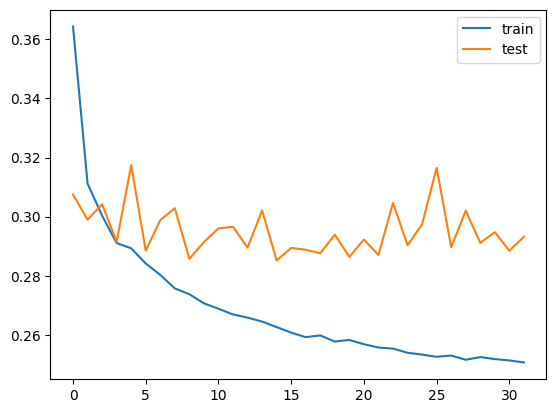

In [7]:
history = fit_default_parameters(model)

plot_loss(history)

This is the smallest training loss we got, but we couldn't get rid of the oscillation in the testing loss.

### 💡 Key Insight

A dense layer treats every pixel **independently** — it has no notion of spatial structure.

**Convolutional layers** solve this by sharing weights across all positions in the image, exactly like the Gaussian and Laplacian filters you built in Labs 7–9!

- uma camada densa que conecta cada pixel a cada neurônio da camada escondida (315k)

---
## Part 2: Replacing the Dense Layer with a Convolutional Layer

Instead of the dense layer, we will now use a convolutional layer with three $3 \times 3$ filters.

The idea is inspired by the scale space, which is based on convolving the image with multiple Gaussian kernels.

In [8]:
model = nn.Sequential(
    nn.Conv2d(1, 3, kernel_size=3),   # (1, 28, 28) -> (3, 26, 26)
    nn.Flatten(),
    nn.Linear(3 * 26 * 26, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=2028, out_features=10, bias=True)
)

Total parameters: 20,320


The size of the output tensor is $3 \times 26 \times 26$, since the borders are ignored and there are three filters.

The number of parameters in the convolutional layer is $30$: for each of the three filters, there are $3 \times 3$ weights and one bias.

Epoch 01/32 — train loss: 0.3825  val loss: 0.2963
Epoch 02/32 — train loss: 0.2960  val loss: 0.2924
Epoch 03/32 — train loss: 0.2846  val loss: 0.2863
Epoch 04/32 — train loss: 0.2761  val loss: 0.2781
Epoch 05/32 — train loss: 0.2700  val loss: 0.2877
Epoch 06/32 — train loss: 0.2648  val loss: 0.2766
Epoch 07/32 — train loss: 0.2606  val loss: 0.2848
Epoch 08/32 — train loss: 0.2563  val loss: 0.2732
Epoch 09/32 — train loss: 0.2545  val loss: 0.2772
Epoch 10/32 — train loss: 0.2522  val loss: 0.2755
Epoch 11/32 — train loss: 0.2489  val loss: 0.2771
Epoch 12/32 — train loss: 0.2481  val loss: 0.2804
Epoch 13/32 — train loss: 0.2460  val loss: 0.2744
Epoch 14/32 — train loss: 0.2448  val loss: 0.2783
Epoch 15/32 — train loss: 0.2435  val loss: 0.2801
Epoch 16/32 — train loss: 0.2419  val loss: 0.2794
Epoch 17/32 — train loss: 0.2418  val loss: 0.2812
Epoch 18/32 — train loss: 0.2406  val loss: 0.2899
Epoch 19/32 — train loss: 0.2392  val loss: 0.2865
Epoch 20/32 — train loss: 0.238

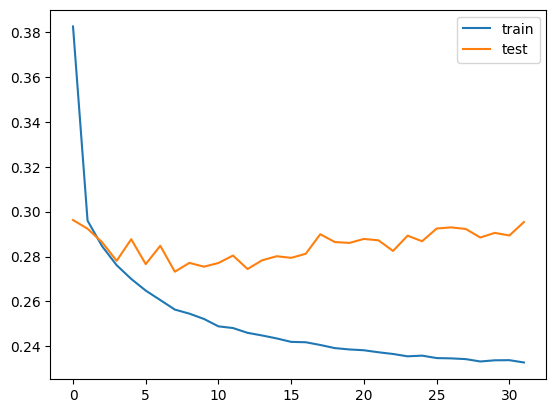

In [9]:
history = fit_default_parameters(model)

plot_loss(history)

- Conv2d: 3 filtros de 3×3 = 3 × 9 = 27 pesos + 3 bias = 30 parâmetros
- Linear: a saída da conv é (3, 26, 26), entao flatten = 3×26×26 = 2028 neurônios ligando a 10 classes = 2028×10 + 10 bias = 20.290 parâmetros

- Grafico com menos picos


---
## Part 3: Adding Another Convolutional Layer

We will now add another convolutional layer that collapses the three channels. The idea is inspired by the scale space Laplacian.

In [10]:
model = nn.Sequential(
    nn.Conv2d(1, 3, kernel_size=3),   # (1, 28, 28) -> (3, 26, 26)
    nn.Conv2d(3, 1, kernel_size=1),   # (3, 26, 26) -> (1, 26, 26)
    nn.Flatten(),
    nn.Linear(1 * 26 * 26, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))
  (1): Conv2d(3, 1, kernel_size=(1, 1), stride=(1, 1))
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=676, out_features=10, bias=True)
)

Total parameters: 6,804


The size of the output tensor is $1 \times 26 \times 26$, since the borders are not ignored and there is one filter.

The number of parameters in the second convolutional layer is $4$: there are $1 \times 1$ weights for each channel, plus one bias.

Epoch 01/32 — train loss: 0.5183  val loss: 0.2877
Epoch 02/32 — train loss: 0.3008  val loss: 0.2873
Epoch 03/32 — train loss: 0.2887  val loss: 0.2768
Epoch 04/32 — train loss: 0.2817  val loss: 0.2858
Epoch 05/32 — train loss: 0.2772  val loss: 0.2802
Epoch 06/32 — train loss: 0.2742  val loss: 0.2742
Epoch 07/32 — train loss: 0.2709  val loss: 0.2781
Epoch 08/32 — train loss: 0.2684  val loss: 0.2756
Epoch 09/32 — train loss: 0.2659  val loss: 0.2666
Epoch 10/32 — train loss: 0.2638  val loss: 0.2729
Epoch 11/32 — train loss: 0.2629  val loss: 0.2787
Epoch 12/32 — train loss: 0.2603  val loss: 0.2705
Epoch 13/32 — train loss: 0.2596  val loss: 0.2660
Epoch 14/32 — train loss: 0.2586  val loss: 0.2662
Epoch 15/32 — train loss: 0.2567  val loss: 0.2670
Epoch 16/32 — train loss: 0.2558  val loss: 0.2722
Epoch 17/32 — train loss: 0.2538  val loss: 0.2741
Epoch 18/32 — train loss: 0.2533  val loss: 0.2673
Epoch 19/32 — train loss: 0.2512  val loss: 0.2732
Epoch 20/32 — train loss: 0.251

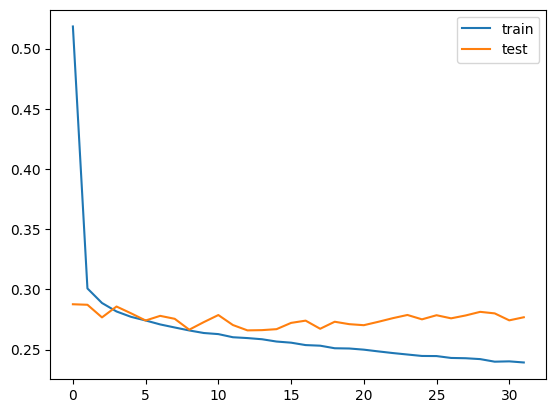

In [11]:
history = fit_default_parameters(model)

plot_loss(history)

- Conv2d(1,3, kernel_size=3): 3 filtros de 3×3 = 27 pesos + 3 bias = 30 parâmetros
- Conv2d(3,1, kernel_size=1): 1 filtro de 1×1 = 3 pesos + 1 bias = 4 parâmetros
- Linear(1×26×26, 10): 676×10 + 10 bias = 6.770 parâmetros

---
## Part 4: Removing Bias

To be more faithful to the idea of representing a scale space, we will add `bias=False` to disable the bias.

In [12]:
model = nn.Sequential(
    nn.Conv2d(1, 3, kernel_size=3, bias=False),   # (1, 28, 28) -> (3, 26, 26)
    nn.Conv2d(3, 1, kernel_size=1, bias=False),   # (3, 26, 26) -> (1, 26, 26)
    nn.Flatten(),
    nn.Linear(1 * 26 * 26, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (1): Conv2d(3, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=676, out_features=10, bias=True)
)

Total parameters: 6,800


Notice the small difference in the number of parameters.

Epoch 01/32 — train loss: 0.4002  val loss: 0.2855
Epoch 02/32 — train loss: 0.2998  val loss: 0.2789
Epoch 03/32 — train loss: 0.2882  val loss: 0.2768
Epoch 04/32 — train loss: 0.2832  val loss: 0.2827
Epoch 05/32 — train loss: 0.2769  val loss: 0.2666
Epoch 06/32 — train loss: 0.2733  val loss: 0.2689
Epoch 07/32 — train loss: 0.2691  val loss: 0.2666
Epoch 08/32 — train loss: 0.2657  val loss: 0.2690
Epoch 09/32 — train loss: 0.2631  val loss: 0.2767
Epoch 10/32 — train loss: 0.2603  val loss: 0.2707
Epoch 11/32 — train loss: 0.2588  val loss: 0.2690
Epoch 12/32 — train loss: 0.2560  val loss: 0.2673
Epoch 13/32 — train loss: 0.2540  val loss: 0.2732
Epoch 14/32 — train loss: 0.2530  val loss: 0.2695
Epoch 15/32 — train loss: 0.2511  val loss: 0.2781
Epoch 16/32 — train loss: 0.2495  val loss: 0.2763
Epoch 17/32 — train loss: 0.2482  val loss: 0.2751
Epoch 18/32 — train loss: 0.2461  val loss: 0.2739
Epoch 19/32 — train loss: 0.2451  val loss: 0.2741
Epoch 20/32 — train loss: 0.244

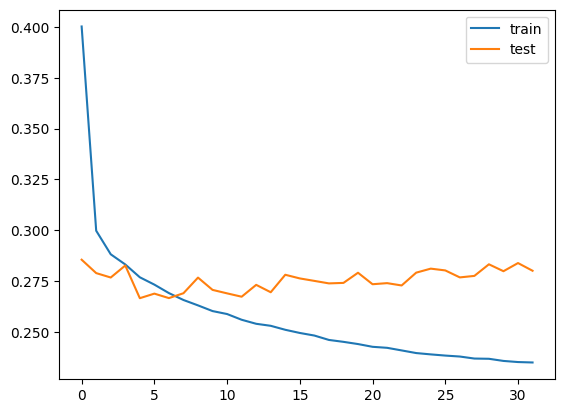

In [13]:
history = fit_default_parameters(model)

plot_loss(history)

---
## Part 5: Re-Revisiting the Activation Parameter

Finally, we will add `nn.ReLU()` activation layers, which was what resulted in a smaller loss but also led to overfitting previously.

In [14]:
model = nn.Sequential(
    nn.Conv2d(1, 3, kernel_size=3, bias=False),   # (1, 28, 28) -> (3, 26, 26)
    nn.ReLU(),
    nn.Conv2d(3, 1, kernel_size=1, bias=False),   # (3, 26, 26) -> (1, 26, 26)
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(1 * 26 * 26, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (1): ReLU()
  (2): Conv2d(3, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (3): ReLU()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=676, out_features=10, bias=True)
)

Total parameters: 6,800


Notice that there is no difference in the number of parameters — `nn.ReLU()` has none.

Epoch 01/32 — train loss: 0.4652  val loss: 0.2985
Epoch 02/32 — train loss: 0.2971  val loss: 0.2789
Epoch 03/32 — train loss: 0.2846  val loss: 0.2733
Epoch 04/32 — train loss: 0.2762  val loss: 0.2666
Epoch 05/32 — train loss: 0.2701  val loss: 0.2700
Epoch 06/32 — train loss: 0.2650  val loss: 0.2686
Epoch 07/32 — train loss: 0.2591  val loss: 0.2664
Epoch 08/32 — train loss: 0.2527  val loss: 0.2593
Epoch 09/32 — train loss: 0.2478  val loss: 0.2599
Epoch 10/32 — train loss: 0.2426  val loss: 0.2524
Epoch 11/32 — train loss: 0.2372  val loss: 0.2535
Epoch 12/32 — train loss: 0.2330  val loss: 0.2479
Epoch 13/32 — train loss: 0.2298  val loss: 0.2477
Epoch 14/32 — train loss: 0.2261  val loss: 0.2469
Epoch 15/32 — train loss: 0.2232  val loss: 0.2501
Epoch 16/32 — train loss: 0.2208  val loss: 0.2463
Epoch 17/32 — train loss: 0.2180  val loss: 0.2460
Epoch 18/32 — train loss: 0.2159  val loss: 0.2492
Epoch 19/32 — train loss: 0.2137  val loss: 0.2472
Epoch 20/32 — train loss: 0.211

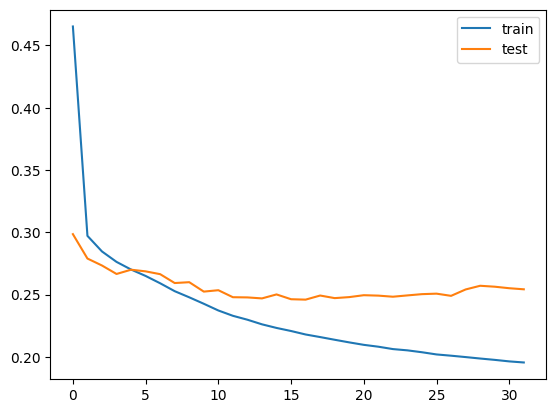

In [15]:
history = fit_default_parameters(model)

plot_loss(history)

---
## Part 6: Putting the Bias Back

Now that we have ReLU activations, let us put the bias back and observe whether it makes a difference.

In [7]:
model = nn.Sequential(
    nn.Conv2d(1, 3, kernel_size=3),   # (1, 28, 28) -> (3, 26, 26)
    nn.ReLU(),
    nn.Conv2d(3, 1, kernel_size=1),   # (3, 26, 26) -> (1, 26, 26)
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(1 * 26 * 26, 10),
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(3, 1, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=676, out_features=10, bias=True)
)

Total parameters: 6,804


Notice that we cannot simply add parameters and expect the results to always improve.

Epoch 01/32 — train loss: 0.4511  val loss: 0.2838
Epoch 02/32 — train loss: 0.2927  val loss: 0.2774
Epoch 03/32 — train loss: 0.2810  val loss: 0.2693
Epoch 04/32 — train loss: 0.2728  val loss: 0.2651
Epoch 05/32 — train loss: 0.2645  val loss: 0.2612
Epoch 06/32 — train loss: 0.2560  val loss: 0.2540
Epoch 07/32 — train loss: 0.2507  val loss: 0.2529
Epoch 08/32 — train loss: 0.2447  val loss: 0.2524
Epoch 09/32 — train loss: 0.2400  val loss: 0.2562
Epoch 10/32 — train loss: 0.2355  val loss: 0.2444
Epoch 11/32 — train loss: 0.2329  val loss: 0.2377
Epoch 12/32 — train loss: 0.2290  val loss: 0.2400
Epoch 13/32 — train loss: 0.2252  val loss: 0.2419
Epoch 14/32 — train loss: 0.2236  val loss: 0.2442
Epoch 15/32 — train loss: 0.2222  val loss: 0.2376
Epoch 16/32 — train loss: 0.2185  val loss: 0.2433
Epoch 17/32 — train loss: 0.2162  val loss: 0.2477
Epoch 18/32 — train loss: 0.2143  val loss: 0.2325
Epoch 19/32 — train loss: 0.2123  val loss: 0.2324
Epoch 20/32 — train loss: 0.210

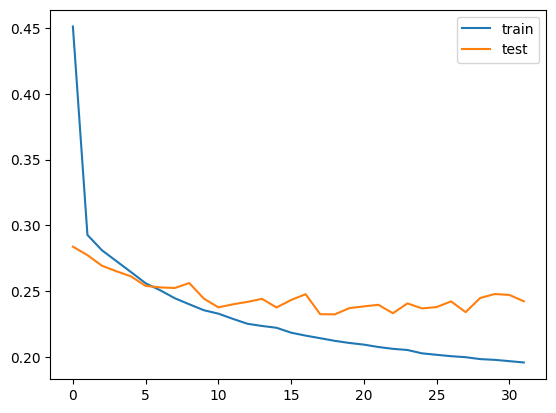

In [8]:
history = fit_default_parameters(model)

plot_loss(history)

---
## 🧠 Connection to Scale Space

**Everything you hand-built in Lab 9 is what convolutional layers do automatically!**

### Scale Space → CNN Layers

**Lab 9 (handcrafted):**
1. ✅ Designed Gaussian filters manually with chosen σ values
2. ✅ Built Laplacian / DoG filters to detect edges
3. ✅ Decided how to consolidate across scales
4. ✅ Applied unsharp masking to enhance details

**Lab 10 (learned):**
1. ✅ `Conv2d(1, 3, kernel_size=3)` learns 3 filters — just like S_σ, S_2σ, S_3σ
2. ✅ `Conv2d(3, 1, kernel_size=1)` collapses channels — just like the DoG / Laplacian step
3. ✅ `nn.ReLU()` keeps only positive responses — like thresholding edge maps
4. ✅ The network decides **which filters matter** by minimising the loss

### The Key Difference

**Handcrafted filters (Labs 7–9):**
- You chose the filter shapes
- You chose σ values
- You decided the consolidation strategy

**Learned filters (Lab 10):**
- Network **learns optimal filters** from data
- Network **learns how to combine channels**
- Network **learns what features minimise the loss**

**But the underlying principles are exactly the same!**

---
## ✏️ Challenge

Can you squeeze more improvement from this point? This time, however, I do *not* want you to explore the API reference. This time, I want you to *explain* the modifications. Why do you think they make sense?

In [6]:
# ── Your code here ──────────────────────────────────────────────────────────

model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3),   # mais filtros = mais padrões aprendidos
    nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * 24 * 24, 10),
)


print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

# ────────────────────────────────────────────────────────────────────────────

print("Complete the challenge above")

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): ReLU()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=18432, out_features=10, bias=True)
)

Total parameters: 189,130
Complete the challenge above


*write your rationale here*


cada conv reduz o spatial em 2 (sem padding, kernel 3x3: 28->26->24), então após duas convs tem feature de 24x24
com 32 filtros na última conv, o flatten produz 32×24×24 = 18432 features, que aí a linear mapeia pras 10 classes.

Epoch 01/32 — train loss: 0.1436  val loss: 0.0606
Epoch 02/32 — train loss: 0.0512  val loss: 0.0484
Epoch 03/32 — train loss: 0.0344  val loss: 0.0515
Epoch 04/32 — train loss: 0.0233  val loss: 0.0452
Epoch 05/32 — train loss: 0.0154  val loss: 0.0633
Epoch 06/32 — train loss: 0.0129  val loss: 0.0502
Epoch 07/32 — train loss: 0.0093  val loss: 0.0716
Epoch 08/32 — train loss: 0.0073  val loss: 0.0605
Epoch 09/32 — train loss: 0.0050  val loss: 0.0675
Epoch 10/32 — train loss: 0.0043  val loss: 0.0722
Epoch 11/32 — train loss: 0.0046  val loss: 0.0862
Epoch 12/32 — train loss: 0.0034  val loss: 0.0852
Epoch 13/32 — train loss: 0.0036  val loss: 0.0864
Epoch 14/32 — train loss: 0.0030  val loss: 0.0728
Epoch 15/32 — train loss: 0.0024  val loss: 0.0983
Epoch 16/32 — train loss: 0.0023  val loss: 0.1040
Epoch 17/32 — train loss: 0.0022  val loss: 0.1005
Epoch 18/32 — train loss: 0.0023  val loss: 0.0981
Epoch 19/32 — train loss: 0.0016  val loss: 0.1102
Epoch 20/32 — train loss: 0.001

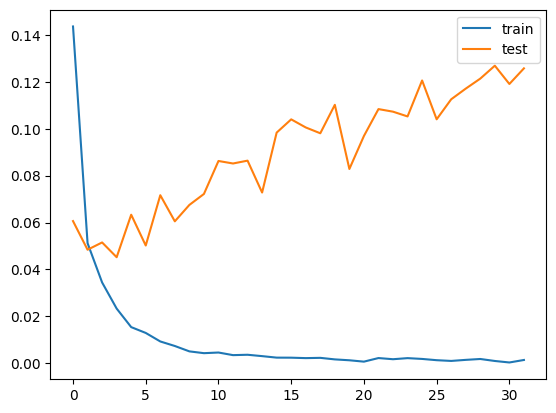

In [7]:
history = fit_default_parameters(model)

plot_loss(history)

usei duas convoluções 3×3 sem padding, mas o modelo overfitou: o train loss foi quase a zero enquanto o val loss continuou subindo

entao isso quer dizer   que a rede decorou o treino em vez de aprender

---
### ✏️ Final Reflection (+1 point)

Answer these questions:

1. **Why does a convolutional layer have far fewer parameters than a dense layer for the same image size?**

2. **What is the role of the $1 \times 1$ convolution in our two-layer network?**

3. **How does today's content connect to the scale-space pyramid from Lab 9?**

4. **Why might disabling bias be useful when trying to mimic a Gaussian filter?**

1. a conv compartilha os mesmos pesos do filtro em toda a imagem,
 uma dense layer conecta cada pixel a cada neurônio,
a conv aprende o filtro uma vez e aplica em todo lugar


2. o kernel 1×1 combina os 3 mapas de feature em 1, aprendendo o peso de cada um, sem olhar pra vizinhança espacial


3. No lab 9 foi criado manualmente filtros em múltiplas escalas e como combina los. A CNN faz isso, só que aprende os filtros e a combinação automaticamente minimizando o loss


4. gaussiano não adiciona nada a imagem, só suaviza. Bias adicionaria um valor fixo ao output(o valor resultante após aplicar o filtro em cada posição da imagem). entao distorceria o resultado

In [ ]:
# Your reflection:

# 1. Why fewer parameters than a dense layer?
#    ...

# 2. Role of the 1x1 convolution?
#    ...

# 3. Connection to Lab 9 scale-space pyramid?
#    ...

# 4. Why disable bias for Gaussian-like filters?
#    ...